# Feature Engineering

### Objective

This notebook evaluates the predictive features prepared for the
CancerGuard SVM classification model.

The main objectives are to:

- Reproduce the cleaned training and test datasets
- Examine redundancy among the 30 tumour measurement features
- Evaluate individual feature relevance
- Compare feature-ranking techniques
- Construct candidate feature subsets
- Preserve the test set exclusively for final model evaluation
- Determine which feature configurations should be evaluated during modelling

Feature selection decisions will be learned from the training data only
to prevent data leakage.

In [2]:
### Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (f_classif,mutual_info_classif)
%matplotlib inline
warnings.filterwarnings("ignore")

In [ ]:
### Load the dataset
df = pd.read_csv("D:/STUDY/Data_Science_Courses/PROJECTS/2.CancerGuard-SVM/CancerGuard---SVM-Cancer-Detection-API/data/Breast-Cancer_data.csv")
df.head()

Raw dataset shape: (569, 33)


In [5]:
print("Raw dataset shape:", df.shape)

Raw dataset shape: (569, 33)


### Step 1 — Reproduce cleaning

In [6]:
df_clean = df.drop(
    columns=["id", "Unnamed: 32"]
).copy()

df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Cleaned dataset shape:", df_clean.shape)

print("\nTarget distribution:")
print(df_clean["diagnosis"].value_counts().sort_index())

Cleaned dataset shape: (569, 31)

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


#### Step 1.1 — Separate X and y

In [7]:
X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (569, 30)
y shape: (569,)
Number of features: 30


#### Step 1.2 — Reproduce the exact train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Training set: (455, 30)
Test set    : (114, 30)

Training target distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test target distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


### Step 2 — Understand the 30-Feature Structure

#### 2.1 Identify feature families

In [9]:
## GROUP FEATURES BY MEASUREMENT TYPE
mean_features = [
    col for col in X_train.columns
    if col.endswith("_mean")
]

se_features = [
    col for col in X_train.columns
    if col.endswith("_se")
]

worst_features = [
    col for col in X_train.columns
    if col.endswith("_worst")
]

print("Mean features :", len(mean_features))
print("SE features   :", len(se_features))
print("Worst features:", len(worst_features))

print("\nTotal grouped features:",
      len(mean_features) +
      len(se_features) +
      len(worst_features))

Mean features : 10
SE features   : 10
Worst features: 10

Total grouped features: 30


#### 2.2 Display the three groups

In [10]:
feature_groups = pd.DataFrame({
    "Mean_Features": mean_features,
    "SE_Features": se_features,
    "Worst_Features": worst_features
})

display(feature_groups)

,Mean_Features,SE_Features,Worst_Features
0,radius_mean,radius_se,radius_worst
1,texture_mean,texture_se,texture_worst
2,perimeter_mean,perimeter_se,perimeter_worst
3,area_mean,area_se,area_worst
4,smoothness_mean,smoothness_se,smoothness_worst
5,compactness_mean,compactness_se,compactness_worst
6,concavity_mean,concavity_se,concavity_worst
7,concave points_mean,concave points_se,concave points_worst
8,symmetry_mean,symmetry_se,symmetry_worst
9,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst


### Step 3 — Training-Only Correlation Analysis

#### 3.1 Calculate training correlations

In [11]:
train_corr_matrix = X_train.corr()

print(
    "Training correlation matrix shape:",
    train_corr_matrix.shape
)

Training correlation matrix shape: (30, 30)


#### 3.2 Identify highly correlated pairs

In [12]:
high_corr_pairs = []

columns = train_corr_matrix.columns

for i in range(len(columns)):
    for j in range(i):

        correlation = train_corr_matrix.iloc[i, j]

        if abs(correlation) >= 0.90:

            high_corr_pairs.append({
                "Feature_1": columns[i],
                "Feature_2": columns[j],
                "Correlation": correlation,
                "Absolute_Correlation": abs(correlation)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df = high_corr_df.sort_values(
    "Absolute_Correlation",
    ascending=False
).reset_index(drop=True)

print(
    "Number of highly correlated feature pairs:",
    len(high_corr_df)
)

display(high_corr_df)

Number of highly correlated feature pairs: 21


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,perimeter_mean,radius_mean,0.997815,0.997815
1,perimeter_worst,radius_worst,0.993719,0.993719
2,area_mean,radius_mean,0.986740,0.986740
3,area_mean,perimeter_mean,0.985960,0.985960
4,area_worst,radius_worst,0.983107,0.983107
5,area_worst,perimeter_worst,0.976665,0.976665
6,perimeter_se,radius_se,0.974705,0.974705
7,perimeter_worst,perimeter_mean,0.970006,0.970006
8,radius_worst,perimeter_mean,0.969332,0.969332
9,radius_worst,radius_mean,0.969256,0.969256


### Step 4 — ANOVA F-Test Feature Relevance

#### 4.1 Calculate ANOVA F-scores

In [13]:
f_scores, p_values = f_classif(
    X_train,
    y_train
)

anova_results = pd.DataFrame({
    "Feature": X_train.columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

anova_results = anova_results.sort_values(
    "F_Score",
    ascending=False
).reset_index(drop=True)

display(anova_results)

,Feature,F_Score,P_Value
0,concave points_worst,733.724933,8.778594e-97
1,perimeter_worst,717.246487,2.093046e-95
2,radius_worst,692.861395,2.483688e-93
3,concave points_mean,684.526845,1.300875e-92
4,perimeter_mean,548.413236,4.687521e-80
5,area_worst,522.188947,1.932387e-77
6,radius_mean,511.274848,2.485053e-76
7,area_mean,444.857518,2.691158e-69
8,concavity_mean,397.592082,5.781926e-64
9,concavity_worst,319.507776,1.820808e-54


#### 4.2 Display Top 15

In [14]:
top15_anova = anova_results.head(15)

display(top15_anova)

,Feature,F_Score,P_Value
0,concave points_worst,733.724933,8.778594e-97
1,perimeter_worst,717.246487,2.093046e-95
2,radius_worst,692.861395,2.483688e-93
3,concave points_mean,684.526845,1.300875e-92
4,perimeter_mean,548.413236,4.687521e-80
5,area_worst,522.188947,1.932387e-77
6,radius_mean,511.274848,2.485053e-76
7,area_mean,444.857518,2.691158e-69
8,concavity_mean,397.592082,5.781926e-64
9,concavity_worst,319.507776,1.820808e-54


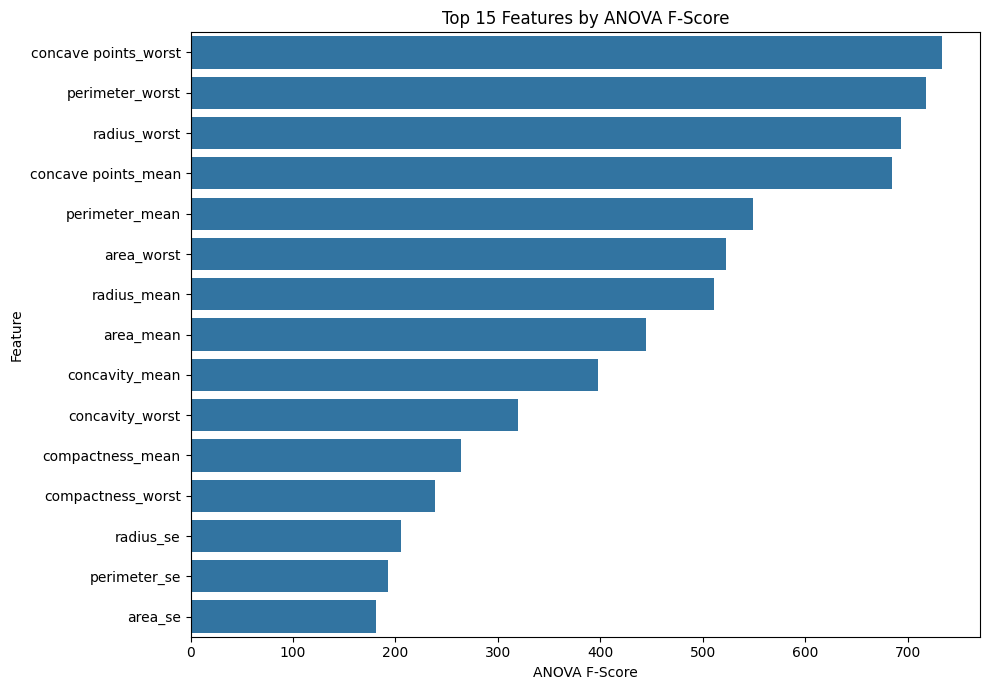

In [15]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15_anova,
    x="F_Score",
    y="Feature"
)

plt.title("Top 15 Features by ANOVA F-Score")
plt.xlabel("ANOVA F-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

ANOVA measures individual statistical separation between benign and malignant classes. Now Mutual Information gives us another perspective by detecting non-linear/non-monotonic dependency between each feature and diagnosis.

### Step 5 — Mutual Information Feature Ranking

#### 5.1 — Calculate Mutual Information

In [16]:
## MUTUAL INFORMATION FEATURE SCORES

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
})

mi_results = mi_results.sort_values(
    "MI_Score",
    ascending=False
).reset_index(drop=True)

display(mi_results)

,Feature,MI_Score
0,radius_worst,0.461221
1,perimeter_worst,0.454559
2,area_worst,0.453342
3,concave points_mean,0.445956
4,concave points_worst,0.432900
5,perimeter_mean,0.409301
6,area_mean,0.374696
7,radius_mean,0.373251
8,concavity_mean,0.354085
9,area_se,0.350009


#### 5.2 — Top 15 Mutual Information Features

In [ ]:
## TOP 15 FEATURES BY MUTUAL INFORMATION
top15_mi = mi_results.head(15)

display(top15_mi)

,Feature,MI_Score
0,radius_worst,0.461221
1,perimeter_worst,0.454559
2,area_worst,0.453342
3,concave points_mean,0.445956
4,concave points_worst,0.432900
5,perimeter_mean,0.409301
6,area_mean,0.374696
7,radius_mean,0.373251
8,concavity_mean,0.354085
9,area_se,0.350009


#### 5.3 — Visualise the ranking

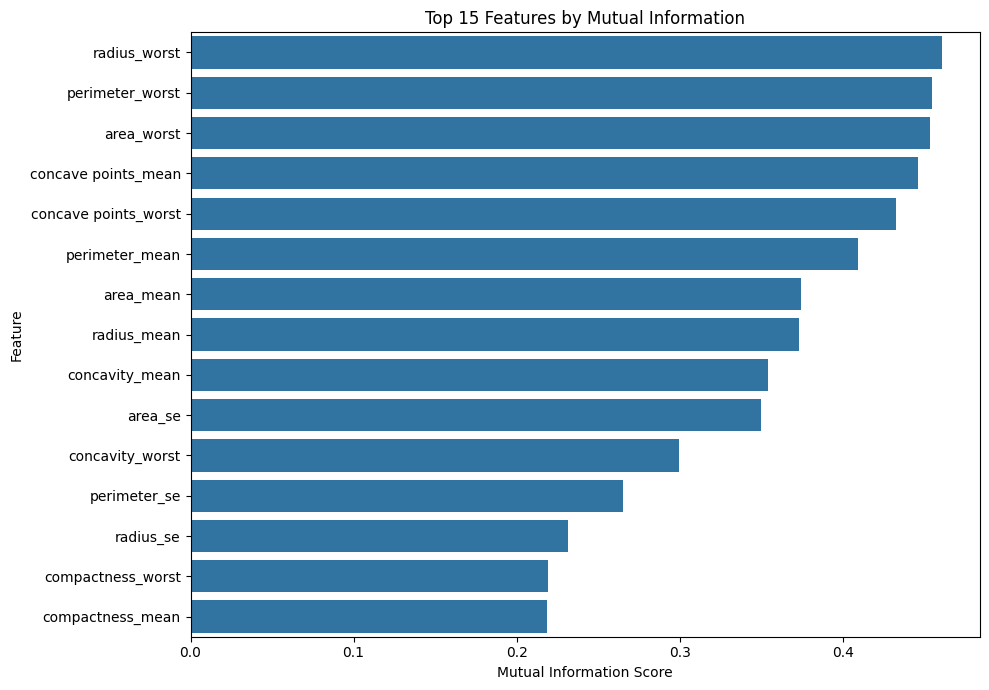

In [18]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15_mi,
    x="MI_Score",
    y="Feature"
)

plt.title("Top 15 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Step 6 — Compare ANOVA and Mutual Information Rankings

In [19]:
## COMPARE ANOVA AND MUTUAL INFORMATION RANKINGS

anova_rank = anova_results.copy()
anova_rank["ANOVA_Rank"] = range(1, len(anova_rank) + 1)

mi_rank = mi_results.copy()
mi_rank["MI_Rank"] = range(1, len(mi_rank) + 1)

ranking_comparison = pd.merge(
    anova_rank[["Feature", "F_Score", "ANOVA_Rank"]],
    mi_rank[["Feature", "MI_Score", "MI_Rank"]],
    on="Feature"
)

ranking_comparison["Average_Rank"] = (
    ranking_comparison["ANOVA_Rank"] +
    ranking_comparison["MI_Rank"]
) / 2

ranking_comparison = ranking_comparison.sort_values(
    "Average_Rank"
).reset_index(drop=True)

display(ranking_comparison)

,Feature,F_Score,ANOVA_Rank,MI_Score,MI_Rank,Average_Rank
0,perimeter_worst,717.246487,2,0.454559,2,2.0
1,radius_worst,692.861395,3,0.461221,1,2.0
2,concave points_worst,733.724933,1,0.432900,5,3.0
3,concave points_mean,684.526845,4,0.445956,4,4.0
4,area_worst,522.188947,6,0.453342,3,4.5
5,perimeter_mean,548.413236,5,0.409301,6,5.5
6,radius_mean,511.274848,7,0.373251,8,7.5
7,area_mean,444.857518,8,0.374696,7,7.5
8,concavity_mean,397.592082,9,0.354085,9,9.0
9,concavity_worst,319.507776,10,0.299396,11,10.5


In [20]:
## TOP 15 CONSENSUS FEATURES
top15_consensus = ranking_comparison.head(15)

display(top15_consensus)

,Feature,F_Score,ANOVA_Rank,MI_Score,MI_Rank,Average_Rank
0,perimeter_worst,717.246487,2,0.454559,2,2.0
1,radius_worst,692.861395,3,0.461221,1,2.0
2,concave points_worst,733.724933,1,0.432900,5,3.0
3,concave points_mean,684.526845,4,0.445956,4,4.0
4,area_worst,522.188947,6,0.453342,3,4.5
5,perimeter_mean,548.413236,5,0.409301,6,5.5
6,radius_mean,511.274848,7,0.373251,8,7.5
7,area_mean,444.857518,8,0.374696,7,7.5
8,concavity_mean,397.592082,9,0.354085,9,9.0
9,concavity_worst,319.507776,10,0.299396,11,10.5


### Step 7 — Cross-Validated Feature-Subset Comparison

#### 7.1 — Create candidate feature sets

We'll compare:

- All 30 features
- Top 20 consensus
- Top 15 consensus
- Top 10 consensus
- Top 5 consensus

In [22]:
candidate_feature_sets = {
    "All_30": list(X_train.columns),
    "Top_20": ranking_comparison.head(20)["Feature"].tolist(),
    "Top_15": ranking_comparison.head(15)["Feature"].tolist(),
    "Top_10": ranking_comparison.head(10)["Feature"].tolist(),
    "Top_5": ranking_comparison.head(5)["Feature"].tolist()
}

for name, features in candidate_feature_sets.items():
    print(f"{name}: {len(features)} features")

All_30: 30 features
Top_20: 20 features
Top_15: 15 features
Top_10: 10 features
Top_5: 5 features


#### 7.2 — Set up SVM + scaling

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### 7.3 — Evaluate every candidate set

In [24]:
from sklearn.model_selection import cross_validate
import pandas as pd

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for set_name, features in candidate_feature_sets.items():

    scores = cross_validate(
        svm_pipeline,
        X_train[features],
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Feature_Set": set_name,
        "N_Features": len(features),

        "Accuracy_Mean": scores["test_accuracy"].mean(),
        "Precision_Mean": scores["test_precision"].mean(),
        "Recall_Mean": scores["test_recall"].mean(),
        "F1_Mean": scores["test_f1"].mean(),
        "ROC_AUC_Mean": scores["test_roc_auc"].mean(),

        "ROC_AUC_Std": scores["test_roc_auc"].std()
    })

feature_set_results = pd.DataFrame(cv_results)

feature_set_results = feature_set_results.sort_values(
    "ROC_AUC_Mean",
    ascending=False
).reset_index(drop=True)

display(feature_set_results)

,Feature_Set,N_Features,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,ROC_AUC_Std
0,All_30,30,0.971429,0.976946,0.947059,0.960987,0.994943,0.004964
1,Top_20,20,0.967033,0.964992,0.947059,0.955287,0.994737,0.006456
2,Top_15,15,0.942857,0.950568,0.894118,0.920807,0.987307,0.007658
3,Top_5,5,0.947253,0.964240,0.894118,0.926317,0.980599,0.012472
4,Top_10,10,0.949451,0.967944,0.894118,0.928929,0.979773,0.012620


#### 7.4 — Compare the results visually

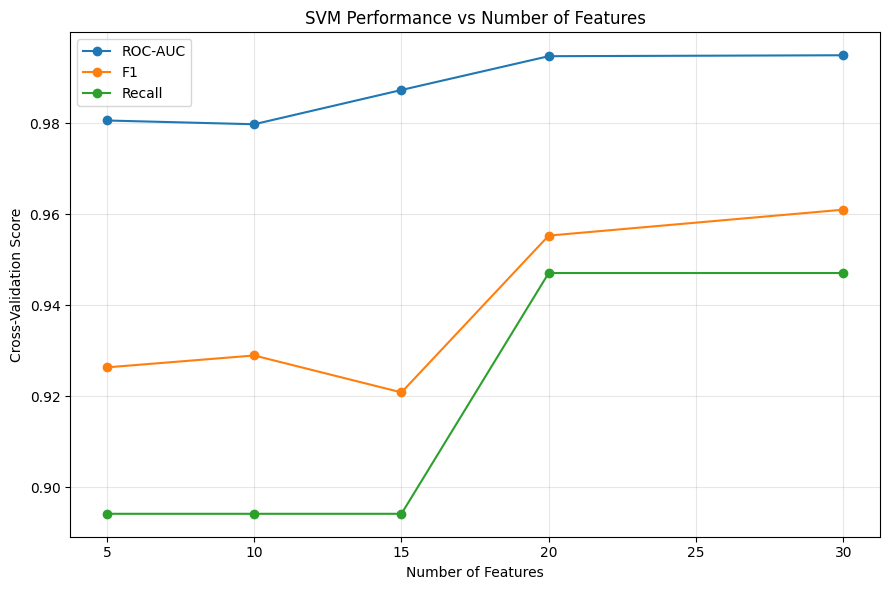

In [25]:
plot_df = feature_set_results.sort_values("N_Features")

plt.figure(figsize=(9, 6))

plt.plot(
    plot_df["N_Features"],
    plot_df["ROC_AUC_Mean"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    plot_df["N_Features"],
    plot_df["F1_Mean"],
    marker="o",
    label="F1"
)

plt.plot(
    plot_df["N_Features"],
    plot_df["Recall_Mean"],
    marker="o",
    label="Recall"
)

plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Score")
plt.title("SVM Performance vs Number of Features")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Although substantial multicollinearity was observed among several morphological measurements, cross-validated feature-subset analysis showed that retaining all 30 predictors produced the strongest overall SVM performance (ROC-AUC = 0.9949, F1 = 0.9610, recall = 0.9471). Reducing the feature space to 20 predictors produced comparable but slightly lower performance, while further reduction to 15 or fewer predictors caused a noticeable decline in recall and F1-score. Therefore, all 30 features were retained for subsequent modelling.

### Step 8 — Finalize Feature Engineering Decision

#### 8.1 — Store final feature list

In [26]:
final_features = list(X_train.columns)

print("Final feature selection completed.")
print(f"Number of retained features: {len(final_features)}")

print("\nFinal features:")
for i, feature in enumerate(final_features, start=1):
    print(f"{i:02d}. {feature}")

Final feature selection completed.
Number of retained features: 30

Final features:
01. radius_mean
02. texture_mean
03. perimeter_mean
04. area_mean
05. smoothness_mean
06. compactness_mean
07. concavity_mean
08. concave points_mean
09. symmetry_mean
10. fractal_dimension_mean
11. radius_se
12. texture_se
13. perimeter_se
14. area_se
15. smoothness_se
16. compactness_se
17. concavity_se
18. concave points_se
19. symmetry_se
20. fractal_dimension_se
21. radius_worst
22. texture_worst
23. perimeter_worst
24. area_worst
25. smoothness_worst
26. compactness_worst
27. concavity_worst
28. concave points_worst
29. symmetry_worst
30. fractal_dimension_worst


#### 8.2 — Save feature metadata

In [27]:
import json
from pathlib import Path

Path("../artifacts").mkdir(parents=True, exist_ok=True)

feature_metadata = {
    "n_features": len(final_features),
    "features": final_features,
    "target": "diagnosis",
    "target_mapping": {
        "B": 0,
        "M": 1
    }
}

with open("../artifacts/feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

print("Feature metadata saved successfully.")

Feature metadata saved successfully.
